# 📥 Step 1: Data Loading

Load Sentinel-2 satellite bands and explore the data structure.

## What This Notebook Does:
- ✅ Install required libraries
- ✅ Load multi-spectral bands (B02, B03, B04, B08)
- ✅ Check data dimensions and quality
- ✅ Visualize raw spectral bands
- ✅ Save loaded data for next steps

---

**Next:** [02_preprocessing.ipynb](02_preprocessing.ipynb) - Calculate NDVI and classify pixels

## Setup: Import Libraries

In [1]:
# Install required packages (uncomment if needed)
# !pip install numpy pandas matplotlib rasterio scikit-learn tensorflow jupyter

import numpy as np
import matplotlib.pyplot as plt
import rasterio
import pickle
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported successfully!")
print(f"NumPy version: {np.__version__}")
print(f"Rasterio version: {rasterio.__version__}")

✅ Libraries imported successfully!
NumPy version: 2.4.2
Rasterio version: 1.5.0


## Load Sentinel-2 Bands

**Sentinel-2 Bands:**
- **B02**: Blue (490 nm) - 10m resolution
- **B03**: Green (560 nm) - 10m resolution
- **B04**: Red (665 nm) - 10m resolution
- **B08**: Near-Infrared / NIR (842 nm) - 10m resolution

In [2]:
# Load Sentinel-2 bands from TIFF files
print("📂 Loading satellite bands...")

B02 = rasterio.open("coastalImage/B02.tiff").read(1).astype(float)  # Blue
B03 = rasterio.open("coastalImage/B03.tiff").read(1).astype(float)  # Green
B04 = rasterio.open("coastalImage/B04.tiff").read(1).astype(float)  # Red
B08 = rasterio.open("coastalImage/B08.tiff").read(1).astype(float)  # NIR

print(f"✅ Bands loaded successfully!")
print(f"\nImage dimensions: {B02.shape}")
print(f"Total pixels: {B02.size:,}")
print(f"\nBand statistics:")
print(f"  B02 (Blue)  - Min: {B02.min():.4f}, Max: {B02.max():.4f}, Mean: {B02.mean():.4f}")
print(f"  B03 (Green) - Min: {B03.min():.4f}, Max: {B03.max():.4f}, Mean: {B03.mean():.4f}")
print(f"  B04 (Red)   - Min: {B04.min():.4f}, Max: {B04.max():.4f}, Mean: {B04.mean():.4f}")
print(f"  B08 (NIR)   - Min: {B08.min():.4f}, Max: {B08.max():.4f}, Mean: {B08.mean():.4f}")

📂 Loading satellite bands...
✅ Bands loaded successfully!

Image dimensions: (424, 480)
Total pixels: 203,520

Band statistics:
  B02 (Blue)  - Min: -9999.0000, Max: 0.3405, Mean: -2129.5218
  B03 (Green) - Min: -9999.0000, Max: 0.3399, Mean: -2129.5251
  B04 (Red)   - Min: -9999.0000, Max: 0.3546, Mean: -2129.5396
  B08 (NIR)   - Min: -9999.0000, Max: 0.4142, Mean: -2129.5444


## Visualize Spectral Bands

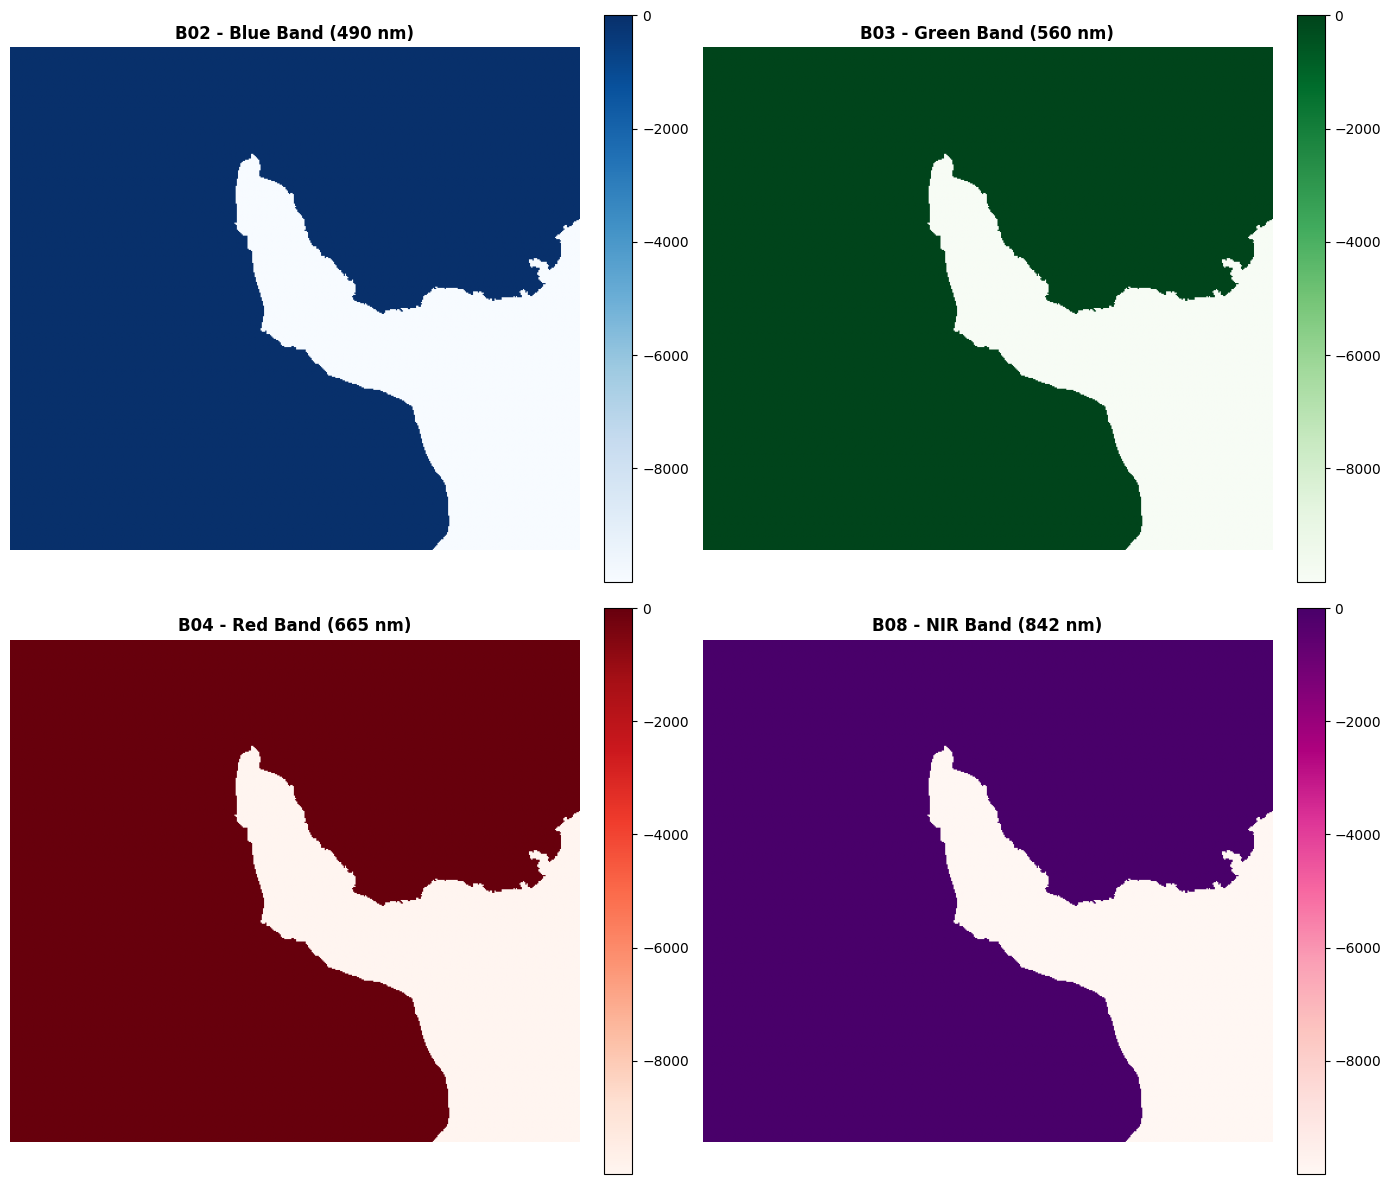

💾 Visualization saved to 'outputs/01_spectral_bands.png'


In [3]:
# Visualize all four bands
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

im1 = axes[0, 0].imshow(B02, cmap='Blues')
axes[0, 0].set_title('B02 - Blue Band (490 nm)', fontsize=12, fontweight='bold')
axes[0, 0].axis('off')
plt.colorbar(im1, ax=axes[0, 0], fraction=0.046, pad=0.04)

im2 = axes[0, 1].imshow(B03, cmap='Greens')
axes[0, 1].set_title('B03 - Green Band (560 nm)', fontsize=12, fontweight='bold')
axes[0, 1].axis('off')
plt.colorbar(im2, ax=axes[0, 1], fraction=0.046, pad=0.04)

im3 = axes[1, 0].imshow(B04, cmap='Reds')
axes[1, 0].set_title('B04 - Red Band (665 nm)', fontsize=12, fontweight='bold')
axes[1, 0].axis('off')
plt.colorbar(im3, ax=axes[1, 0], fraction=0.046, pad=0.04)

im4 = axes[1, 1].imshow(B08, cmap='RdPu')
axes[1, 1].set_title('B08 - NIR Band (842 nm)', fontsize=12, fontweight='bold')
axes[1, 1].axis('off')
plt.colorbar(im4, ax=axes[1, 1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig('outputs/01_spectral_bands.png', dpi=300, bbox_inches='tight')
plt.show()

print("💾 Visualization saved to 'outputs/01_spectral_bands.png'")

## Save Loaded Bands

Save the loaded bands as a pickle file for use in the next notebook.

In [4]:
# Save bands to pickle file for next notebook
import os
os.makedirs('outputs', exist_ok=True)

bands_data = {
    'B02': B02,
    'B03': B03,
    'B04': B04,
    'B08': B08,
    'shape': B02.shape
}

with open('outputs/loaded_bands.pkl', 'wb') as f:
    pickle.dump(bands_data, f)

print("✅ Bands saved to 'outputs/loaded_bands.pkl'")
print("\n" + "="*60)
print("✅ DATA LOADING COMPLETE!")
print("="*60)
print("\n📌 Next Step: Open 02_preprocessing.ipynb to calculate NDVI")

✅ Bands saved to 'outputs/loaded_bands.pkl'

✅ DATA LOADING COMPLETE!

📌 Next Step: Open 02_preprocessing.ipynb to calculate NDVI
